# Analyze TMC sweep (multi-trait, multi-target)

This notebook analyzes one merged sweep run containing multiple traits and multiple target islands.

Included analyses:
1. Running rank trajectories (x = permutation index, y = rank)
2. Importance-per-individual bar plots in a target × trait grid (for selected cal + n_perm)
3. Remove-curve gain (oracle best-k vs k=0 baseline) and non-cheating negative-Shapley removal

In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# =========================
# USER SETTINGS
# =========================
RUN_FOLDER = "outputs/tmc_shapley_sweep_all_traits"   # merged run folder

# Set to None to auto-pick defaults from sweep_summary
SELECT_CAL_VALUE = 150      # n_cal_samples if cal_mode='samples', else cal_fraction
SELECT_N_PERM = 150         # if None, uses max available n_permutations

TOP_K_RANK_LINES = 14         # number of islands to plot in running-rank line plots
SORT_BARS_BY = "phi_per_ind_mean"  # or 'rank_mean'

In [2]:
# Resolve run folder
cwd = Path.cwd().resolve()
requested = Path(RUN_FOLDER)

if requested.is_absolute():
    run_dir = requested
else:
    run_dir = None
    for parent in [cwd, *cwd.parents]:
        candidate = (parent / requested).resolve()
        if candidate.exists():
            run_dir = candidate
            break
    if run_dir is None:
        run_dir = (cwd / requested).resolve()

if not run_dir.exists():
    raise FileNotFoundError(f"Run folder not found: {run_dir}")

summary_path = run_dir / "sweep_summary.json"
if not summary_path.exists():
    raise FileNotFoundError(f"Missing file: {summary_path}")

summary_json = json.loads(summary_path.read_text(encoding="utf-8"))

traits = sorted(summary_json.get("traits", {}).keys())
if not traits:
    raise ValueError("No traits found in sweep_summary.json")

n_perm_grid = sorted([int(x) for x in summary_json.get("n_permutations", [])])
cal_mode = str(summary_json.get("cal_mode", "fraction"))
cal_key = "n_cal_samples" if cal_mode == "samples" else "cal_fraction"
cal_values = sorted([float(x) for x in summary_json.get("cal_values", [])])

if not n_perm_grid or not cal_values:
    raise ValueError("Missing n_permutations or cal_values in sweep_summary.json")

selected_n_perm = int(max(n_perm_grid) if SELECT_N_PERM is None else SELECT_N_PERM)
if selected_n_perm not in n_perm_grid:
    raise ValueError(f"SELECT_N_PERM={selected_n_perm} not in available grid {n_perm_grid}")

selected_cal = float(cal_values[0] if SELECT_CAL_VALUE is None else SELECT_CAL_VALUE)
if not any(np.isclose(selected_cal, cv) for cv in cal_values):
    raise ValueError(f"SELECT_CAL_VALUE={selected_cal} not in available values {cal_values}")

def _near(value, values):
    return min(values, key=lambda x: abs(float(x) - float(value)))

selected_cal = _near(selected_cal, cal_values)

# Collect target codes from summary payload
target_codes = set()
target_name_map = {}
for trait in traits:
    per_target = summary_json["traits"][trait].get("per_target", {})
    for t_str, payload in per_target.items():
        t_code = int(t_str)
        target_codes.add(t_code)
        target_name_map[t_code] = str(payload.get("target_name", t_code))

target_codes = sorted(target_codes)
if not target_codes:
    # fallback: infer from folders
    inferred = set()
    for trait in traits:
        for p in (run_dir / trait).glob("target_*"):
            m = re.match(r"target_(\d+)", p.name)
            if m:
                inferred.add(int(m.group(1)))
    target_codes = sorted(inferred)

print(f"Run folder: {run_dir}")
print(f"Traits ({len(traits)}): {traits}")
print(f"Targets ({len(target_codes)}): {target_codes}")
print(f"cal_mode={cal_mode}, cal_key={cal_key}, selected_cal={selected_cal}")
print(f"selected_n_perm={selected_n_perm}")

Run folder: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\tmc_shapley_sweep_all_traits
Traits (3): ['body_mass', 'tarsus', 'wing']
Targets (3): [3, 5, 14]
cal_mode=samples, cal_key=n_cal_samples, selected_cal=150.0
selected_n_perm=150


## Load per-trait/per-target data

In [3]:
combo_data = {}
missing_combos = []

for trait in traits:
    trait_dir = run_dir / trait
    for target in target_codes:
        tdir = trait_dir / f"target_{target}"
        key = (trait, target)

        files = {
            "remove_summary": tdir / "remove_curve_sweep_summary.csv",
            "remove_rows": tdir / "remove_curve_sweep_rows.csv",
            "gain": tdir / "gain_over_vfull_surface_data.csv",
            "meta": tdir / "sweep_run_metadata.csv",
        }

        if not all(p.exists() for p in files.values()):
            missing_combos.append(key)
            continue

        remove_summary = pd.read_csv(files["remove_summary"])
        remove_rows = pd.read_csv(files["remove_rows"])
        gain = pd.read_csv(files["gain"])
        meta = pd.read_csv(files["meta"])

        # Running-ranking file for selected cal value
        if cal_key == "n_cal_samples":
            token = f"ncal_{int(round(selected_cal))}"
        else:
            token = f"cal_{float(selected_cal):.3f}".replace(".", "p")
        rank_path = tdir / f"running_ranking_{token}.csv"
        rank_df = pd.read_csv(rank_path) if rank_path.exists() else pd.DataFrame()

        combo_data[key] = {
            "target_name": target_name_map.get(target, str(target)),
            "remove_summary": remove_summary,
            "remove_rows": remove_rows,
            "gain": gain,
            "meta": meta,
            "rank": rank_df,
            "rank_path": rank_path,
        }

print(f"Loaded combos: {len(combo_data)}")
if missing_combos:
    print(f"Missing combo files for {len(missing_combos)} trait/target combinations (skipped).")

rank_ready = [k for k, v in combo_data.items() if not v['rank'].empty]
print(f"Running-ranking ready for selected cal: {len(rank_ready)} combos")
if len(rank_ready) == 0:
    print("Note: running_ranking CSVs were not found. Re-run workers with updated script to generate them.")

Loaded combos: 9
Running-ranking ready for selected cal: 9 combos


## 1) Running rank trajectories (line plots)

For each trait-target combo (with available running ranking file), this plots rank trajectories for top islands
defined by final mean importance-per-individual.

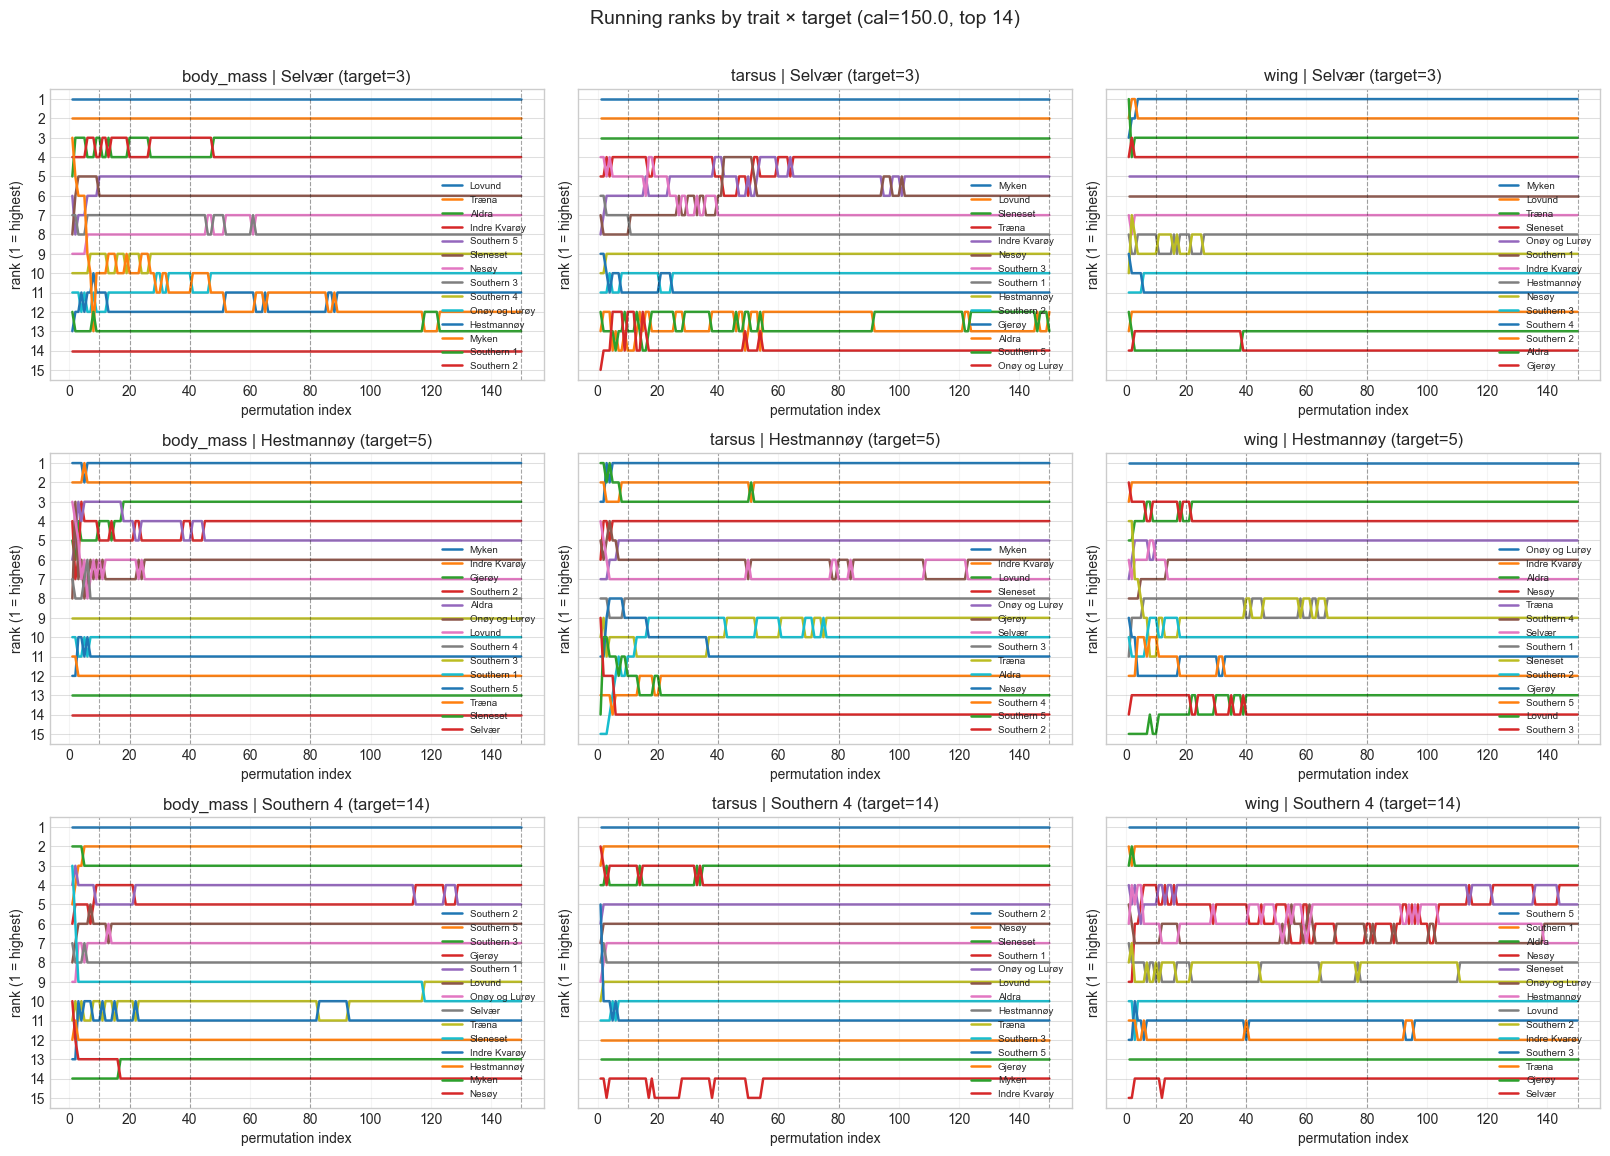

In [4]:
ready = [(tr, tg) for (tr, tg), d in combo_data.items() if not d['rank'].empty]
if not ready:
    print("No running ranking files available for current selected cal setting.")
else:
    n_cols = max(1, len(traits))
    n_rows = max(1, len(target_codes))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.4 * n_cols, 3.8 * n_rows), sharex=False, sharey=True)
    axes = np.array(axes).reshape(n_rows, n_cols)

    trait_to_col = {t: i for i, t in enumerate(traits)}
    target_to_row = {t: i for i, t in enumerate(target_codes)}

    for r in range(n_rows):
        for c in range(n_cols):
            axes[r, c].axis("off")

    for (trait, target), d in combo_data.items():
        r = target_to_row[target]
        c = trait_to_col[trait]
        ax = axes[r, c]
        ax.axis("on")

        rank_df = d['rank'].copy()
        if rank_df.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(no running rank file)")
            continue

        req_cols = {'permutation_index', 'source_island_name', 'phi_per_ind_mean'}
        if not req_cols.issubset(rank_df.columns):
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(missing required rank columns)")
            continue

        # Build DISCRETE running rank from phi_per_ind_mean so each permutation has exactly one island at each rank
        rank_plot = rank_df[['permutation_index', 'source_island_name', 'phi_per_ind_mean']].copy()
        rank_plot = rank_plot.dropna(subset=['permutation_index', 'source_island_name', 'phi_per_ind_mean'])

        rank_plot = rank_plot.sort_values(['permutation_index', 'phi_per_ind_mean', 'source_island_name'], ascending=[True, False, True])
        rank_plot['rank_discrete'] = rank_plot.groupby('permutation_index').cumcount() + 1

        max_p = int(rank_plot['permutation_index'].max())
        final = rank_plot[rank_plot['permutation_index'] == max_p].copy()
        final = final.sort_values('phi_per_ind_mean', ascending=False)
        top_names = final['source_island_name'].head(TOP_K_RANK_LINES).tolist()

        for name in top_names:
            g = rank_plot[rank_plot['source_island_name'] == name].sort_values('permutation_index')
            ax.plot(g['permutation_index'], g['rank_discrete'], linewidth=1.8, label=name)

        for mark in n_perm_grid:
            if mark <= max_p:
                ax.axvline(mark, linestyle='--', linewidth=0.8, alpha=0.35, color='black')

        n_levels = int(rank_plot.groupby('permutation_index')['source_island_name'].nunique().max())
        for yy in range(1, n_levels + 1):
            ax.axhline(yy, linestyle='-', linewidth=0.5, alpha=0.25, color='gray')

        ax.set_ylim(n_levels + 0.5, 0.5)
        ax.set_yticks(np.arange(1, n_levels + 1))
        ax.set_title(f"{trait} | {d['target_name']} (target={target})")
        ax.set_xlabel('permutation index')
        ax.set_ylabel('rank (1 = highest)')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, loc='best')

    fig.suptitle(
        f"Running ranks by trait × target (cal={selected_cal}, top {TOP_K_RANK_LINES})",
        fontsize=14,
        y=1.01
    )
    fig.tight_layout()
    plt.show()

## 2) Importance-per-individual bar plots (target × trait grid)

Uses selected cal setting and selected n_perms.

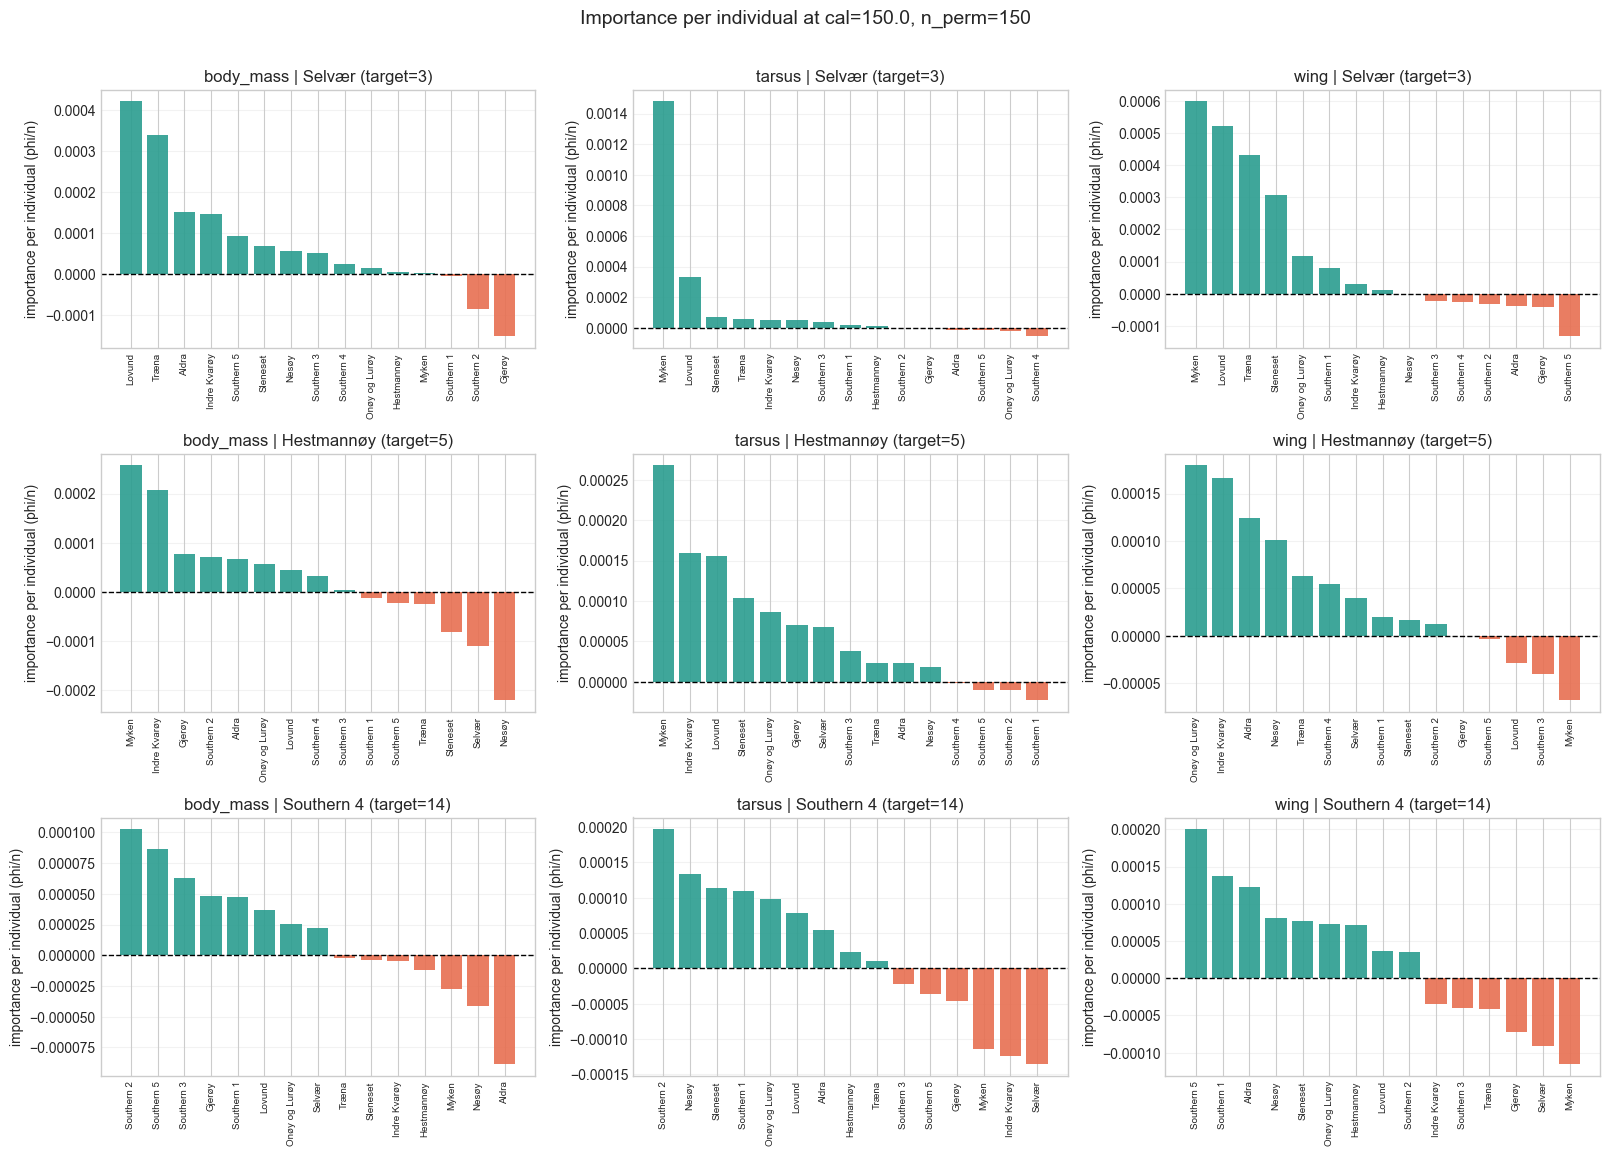

In [5]:
fig, axes = plt.subplots(len(target_codes), len(traits), figsize=(5.4 * len(traits), 3.8 * len(target_codes)), sharex=False, sharey=False)
axes = np.array(axes).reshape(len(target_codes), len(traits))

for i, target in enumerate(target_codes):
    for j, trait in enumerate(traits):
        ax = axes[i, j]
        key = (trait, target)
        if key not in combo_data:
            ax.set_title(f"{trait} | {target_name_map.get(target, str(target))} (target={target})\n(missing)")
            ax.axis('off')
            continue

        d = combo_data[key]
        rank_df = d['rank']

        if rank_df.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(no running ranking file)")
            ax.axis('off')
            continue

        p = min(selected_n_perm, int(rank_df['permutation_index'].max()))
        bar_df = rank_df[rank_df['permutation_index'] == p].copy()
        if bar_df.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(no data at perm={p})")
            ax.axis('off')
            continue

        if SORT_BARS_BY == 'rank_mean':
            bar_df = bar_df.sort_values('rank_mean', ascending=True)
        else:
            bar_df = bar_df.sort_values('phi_per_ind_mean', ascending=False)

        colors = ['#2A9D8F' if v >= 0 else '#E76F51' for v in bar_df['phi_per_ind_mean'].to_numpy(dtype=float)]
        ax.bar(np.arange(len(bar_df)), bar_df['phi_per_ind_mean'].to_numpy(dtype=float), color=colors, alpha=0.9)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(np.arange(len(bar_df)))
        ax.set_xticklabels(bar_df['source_island_name'].astype(str).tolist(), rotation=90, fontsize=7)
        ax.set_ylabel('importance per individual (phi/n)')
        ax.set_title(f"{trait} | {d['target_name']} (target={target})")
        ax.grid(alpha=0.25, axis='y')

fig.suptitle(f"Importance per individual at cal={selected_cal}, n_perm={selected_n_perm}", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 3A) Oracle gain: best k vs k=0 baseline (test-set metric)

For each trait-target combo: heatmap over cal × n_permutations with gain = best remove-curve corr − corr at k=0.

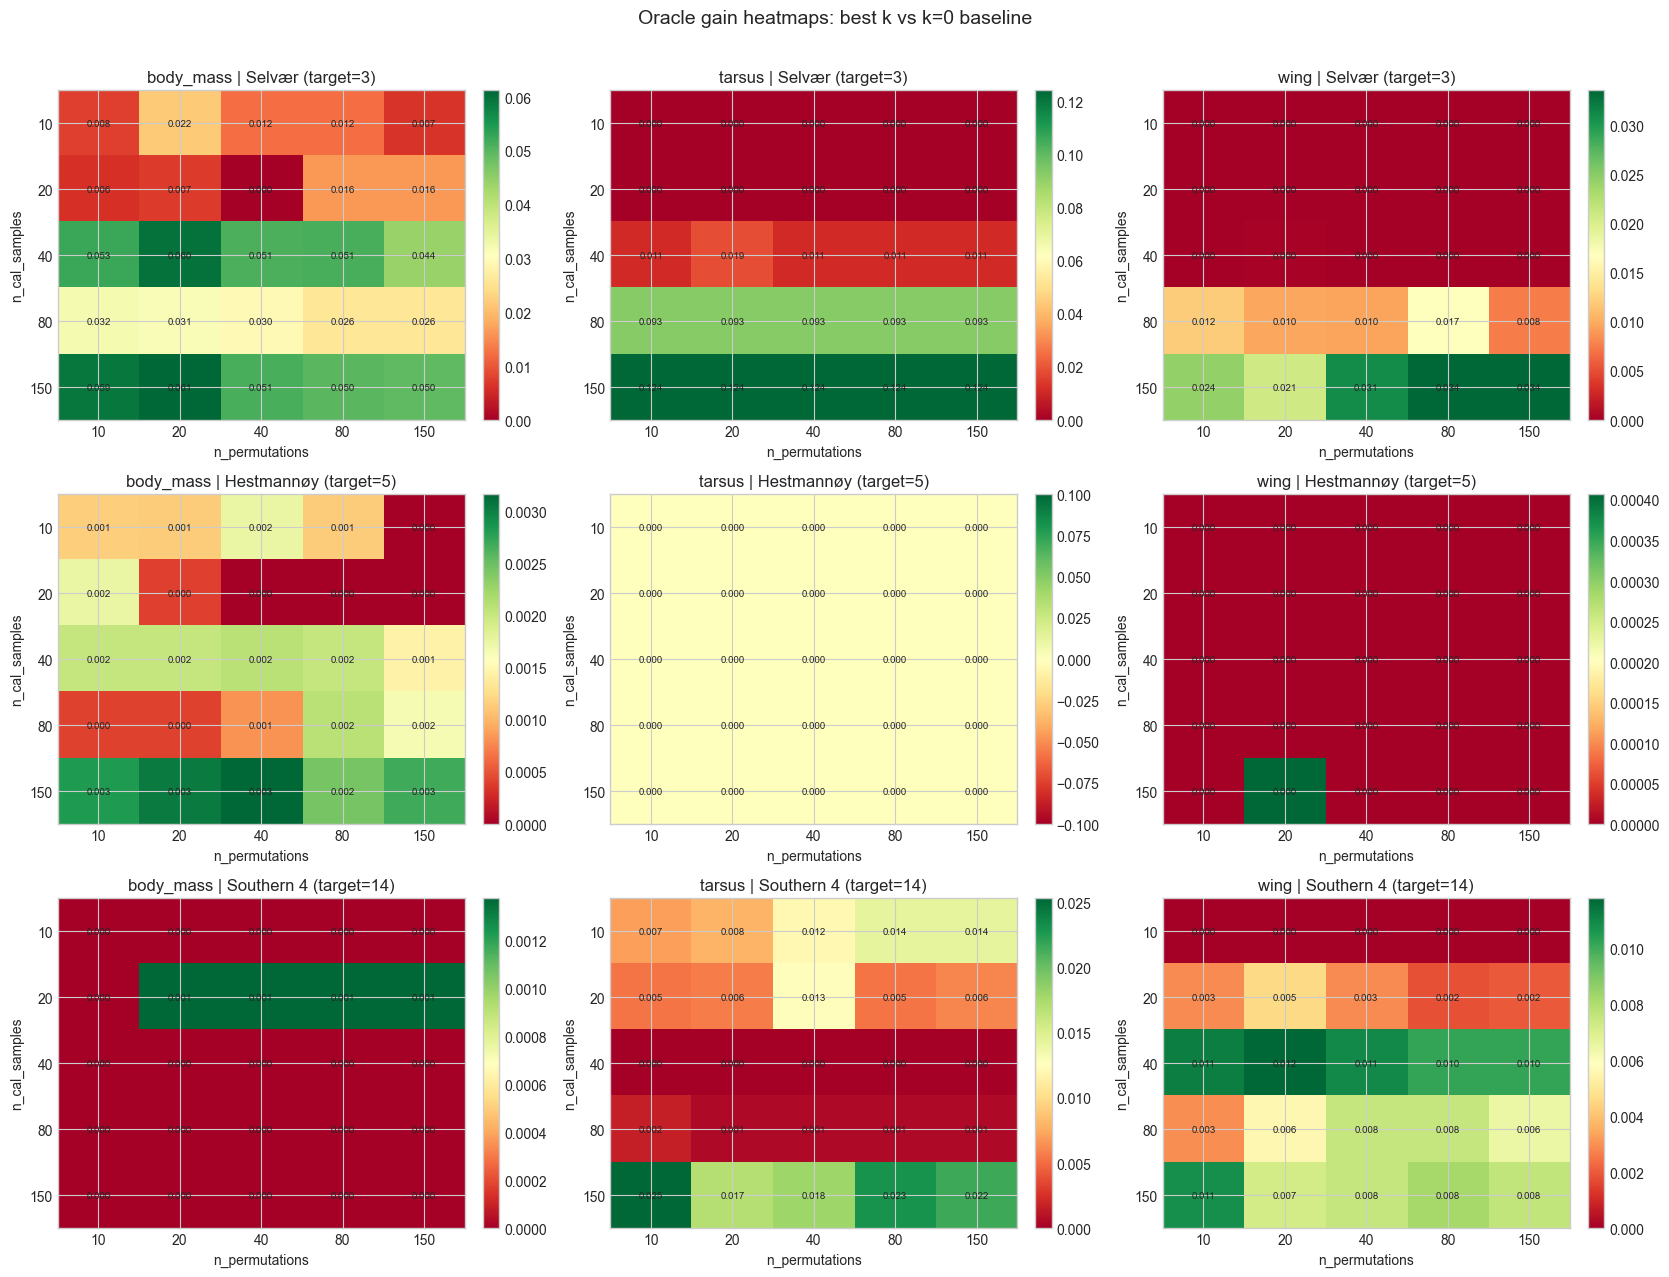

In [6]:
rows = len(target_codes)
cols = len(traits)
fig, axes = plt.subplots(rows, cols, figsize=(5.6 * cols, 4.2 * rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(rows, cols)

for i, target in enumerate(target_codes):
    for j, trait in enumerate(traits):
        ax = axes[i, j]
        key = (trait, target)
        if key not in combo_data:
            ax.axis('off')
            continue

        rs = combo_data[key]['remove_summary'].copy()
        shap = rs[rs['method'] == 'shapley_mean'].copy()
        if shap.empty:
            ax.axis('off')
            continue

        base = (
            shap[shap['n_removed'] == 0][['n_permutations', cal_key, 'corr_mean']]
            .rename(columns={'corr_mean': 'corr_baseline'})
        )
        idx_best = shap.groupby(['n_permutations', cal_key])['corr_mean'].idxmax()
        best = shap.loc[idx_best, ['n_permutations', cal_key, 'n_removed', 'corr_mean']].copy()
        best = best.rename(columns={'corr_mean': 'corr_best', 'n_removed': 'best_n_removed'})

        g = best.merge(base, on=['n_permutations', cal_key], how='left')
        g['gain'] = (g['corr_best'] - g['corr_baseline']).clip(lower=0.0)

        grid = (
            g.pivot(index=cal_key, columns='n_permutations', values='gain')
            .sort_index(axis=0)
            .sort_index(axis=1)
        )

        if grid.empty:
            ax.axis('off')
            continue

        im = ax.imshow(grid.values, aspect='auto', cmap='RdYlGn', vmin=0)
        ax.set_xticks(np.arange(len(grid.columns)))
        ax.set_xticklabels([int(x) for x in grid.columns], rotation=0)
        ax.set_yticks(np.arange(len(grid.index)))
        if cal_key == 'n_cal_samples':
            ax.set_yticklabels([int(round(x)) for x in grid.index])
            ax.set_ylabel('n_cal_samples')
        else:
            ax.set_yticklabels([f"{x:.2f}" for x in grid.index])
            ax.set_ylabel('cal_fraction')

        ax.set_xlabel('n_permutations')
        ax.set_title(f"{trait} | {combo_data[key]['target_name']} (target={target})")

        for rr in range(grid.shape[0]):
            for cc in range(grid.shape[1]):
                val = float(grid.iat[rr, cc])
                ax.text(cc, rr, f"{val:.3f}", ha='center', va='center', fontsize=7)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Oracle gain heatmaps: best k vs k=0 baseline', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 3A.1) Gain vs calibration setting (colored by permutations)

For each trait-target combo, x-axis is calibration setting (`cal_fraction` or `n_cal_samples`), y-axis is gain, and line color encodes `n_permutations`.

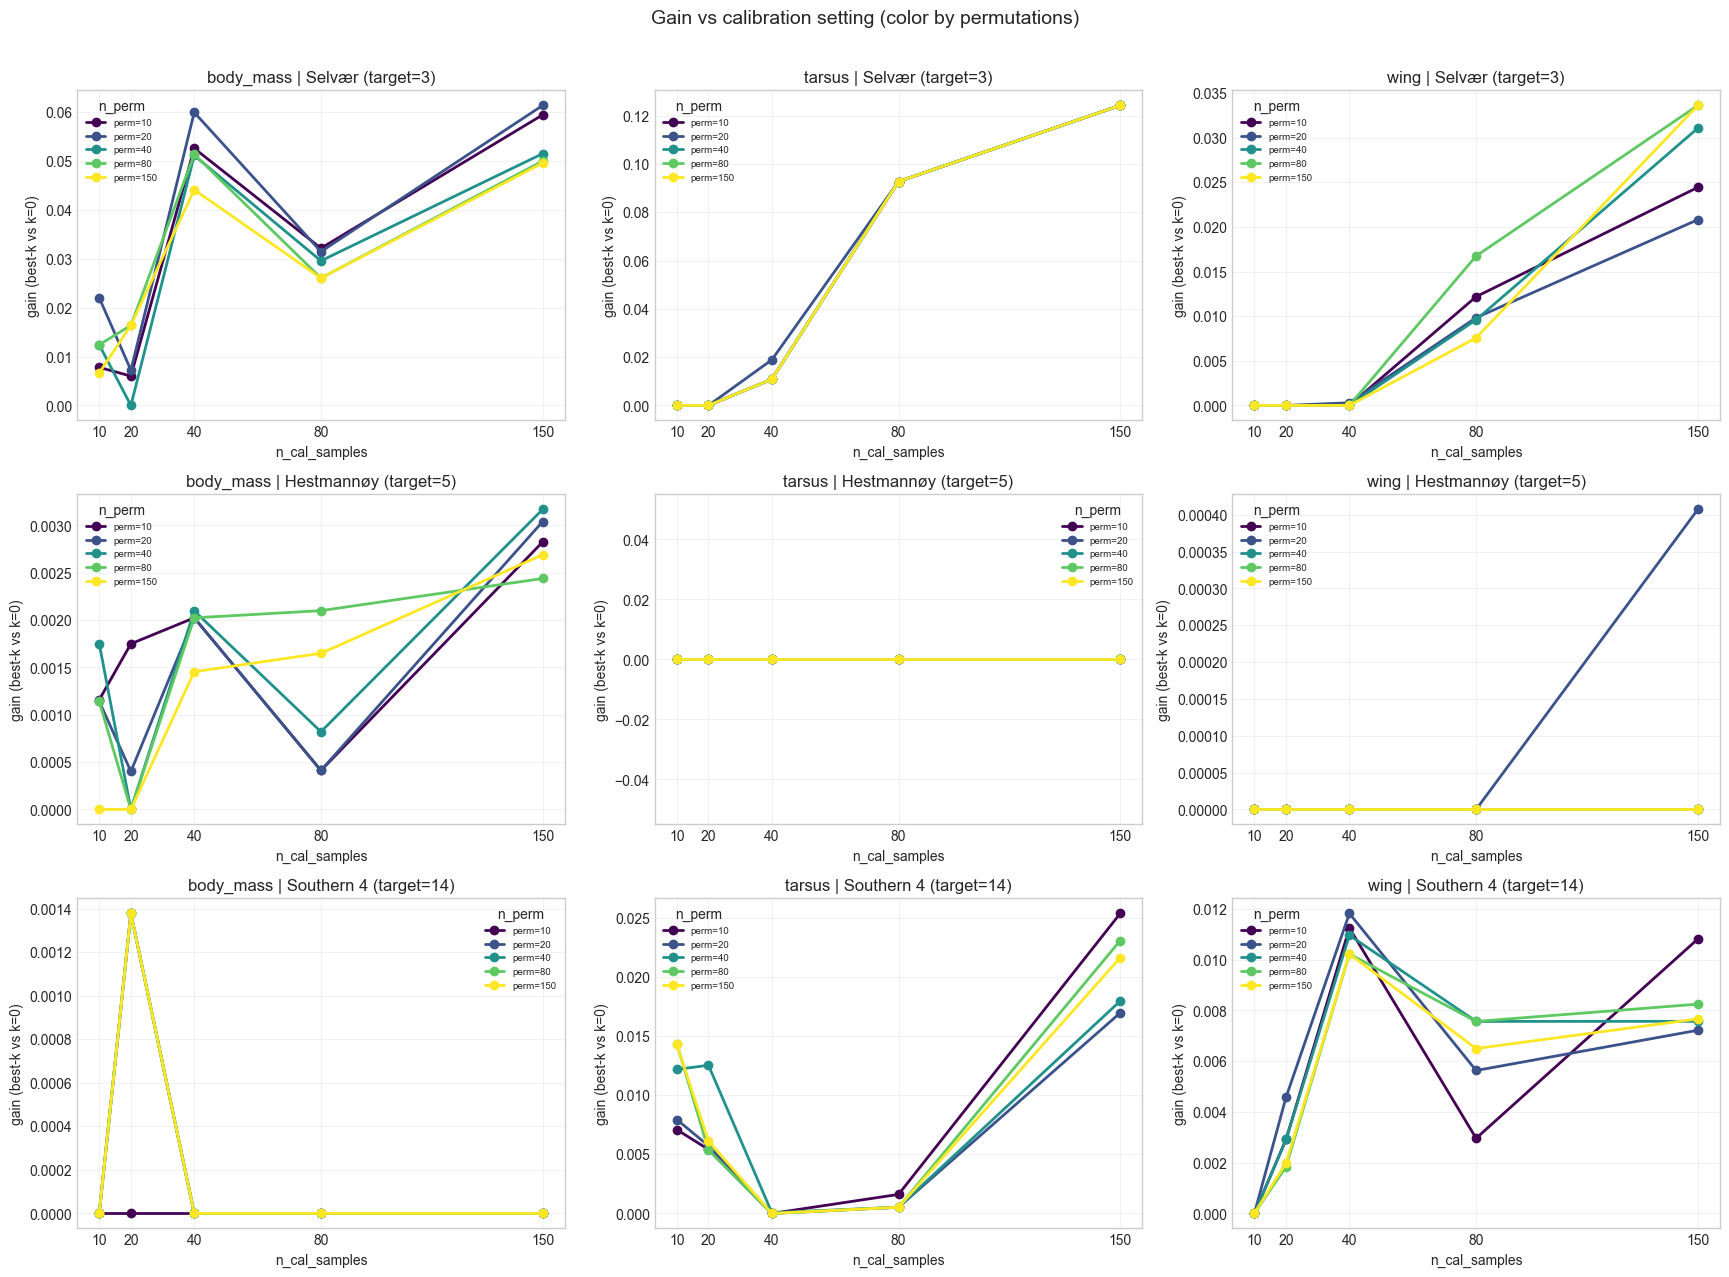

In [7]:
rows = len(target_codes)
cols = len(traits)
fig, axes = plt.subplots(rows, cols, figsize=(5.8 * cols, 4.2 * rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(rows, cols)

for i, target in enumerate(target_codes):
    for j, trait in enumerate(traits):
        ax = axes[i, j]
        key = (trait, target)
        if key not in combo_data:
            ax.axis('off')
            continue

        rs = combo_data[key]['remove_summary'].copy()
        shap = rs[rs['method'] == 'shapley_mean'].copy()
        if shap.empty:
            ax.axis('off')
            continue

        base = (
            shap[shap['n_removed'] == 0][['n_permutations', cal_key, 'corr_mean']]
            .rename(columns={'corr_mean': 'corr_baseline'})
        )
        idx_best = shap.groupby(['n_permutations', cal_key])['corr_mean'].idxmax()
        best = shap.loc[idx_best, ['n_permutations', cal_key, 'corr_mean']].copy()
        best = best.rename(columns={'corr_mean': 'corr_best'})

        g = best.merge(base, on=['n_permutations', cal_key], how='left')
        g['gain'] = (g['corr_best'] - g['corr_baseline']).clip(lower=0.0)

        perm_vals = sorted(g['n_permutations'].astype(int).unique().tolist())
        cmap = plt.get_cmap('viridis', len(perm_vals))

        for idx, p in enumerate(perm_vals):
            gp = g[g['n_permutations'] == p].sort_values(cal_key)
            x = gp[cal_key].to_numpy(dtype=float)
            y = gp['gain'].to_numpy(dtype=float)
            ax.plot(x, y, marker='o', linewidth=2, color=cmap(idx), label=f'perm={p}')

        if cal_key == 'n_cal_samples':
            ax.set_xlabel('n_cal_samples')
            x_ticks = sorted(g[cal_key].unique().tolist())
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([int(round(x)) for x in x_ticks])
        else:
            ax.set_xlabel('cal_fraction')

        ax.set_ylabel('gain (best-k vs k=0)')
        ax.set_title(f"{trait} | {combo_data[key]['target_name']} (target={target})")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7, loc='best', title='n_perm')

fig.suptitle('Gain vs calibration setting (color by permutations)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 3B) Non-cheating gain: remove all negative-Shapley islands

For each trait-target combo, this computes k_neg per repeat from running phi (selected n_perm), then evaluates
gain at k_neg against repeat baseline k=0.

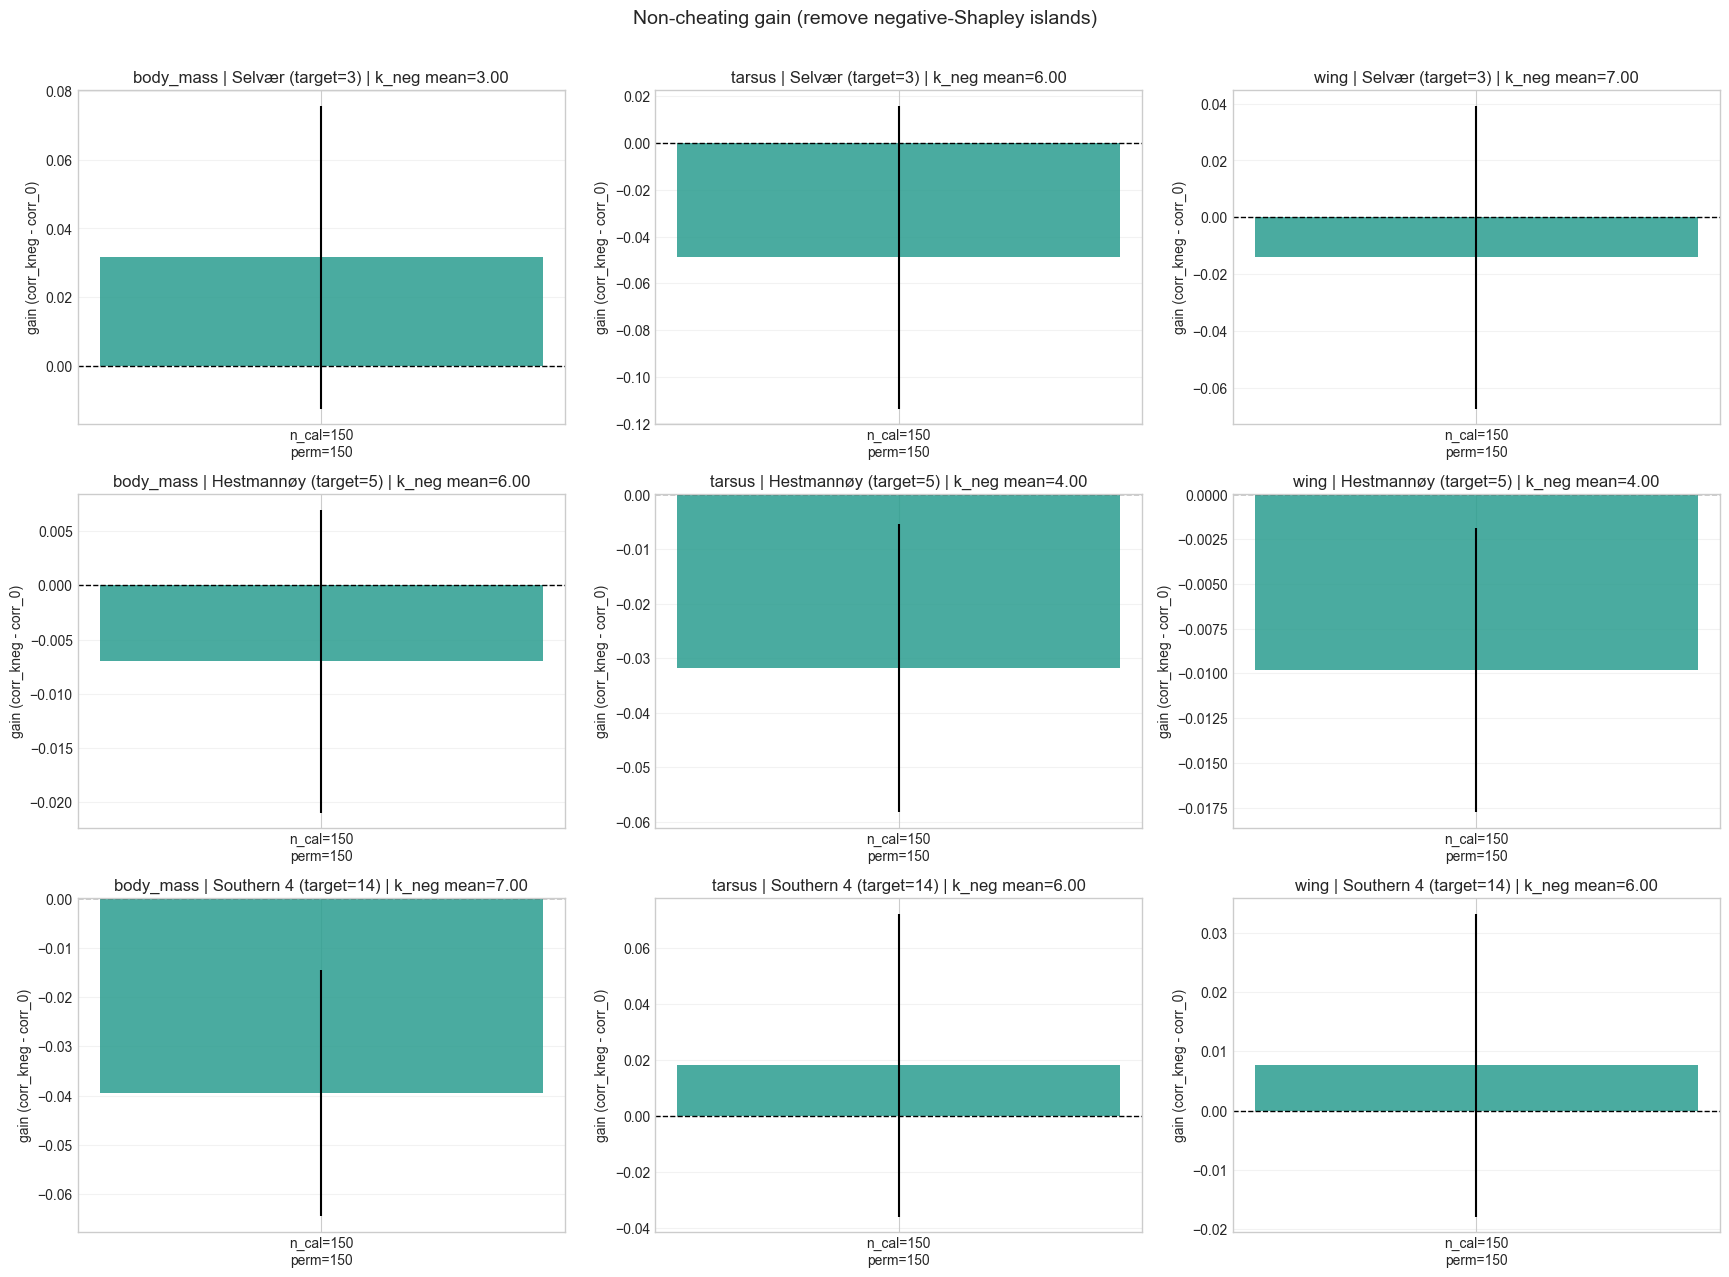

In [8]:
rows = len(target_codes)
cols = len(traits)
fig, axes = plt.subplots(rows, cols, figsize=(5.8 * cols, 4.2 * rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(rows, cols)

for i, target in enumerate(target_codes):
    for j, trait in enumerate(traits):
        ax = axes[i, j]
        key = (trait, target)
        if key not in combo_data:
            ax.axis('off')
            continue

        d = combo_data[key]
        rank_df = d['rank']
        raw = d['remove_rows'].copy()

        if rank_df.empty or raw.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(missing running-rank or remove rows)")
            ax.axis('off')
            continue

        # restrict to selected cal
        if cal_key not in rank_df.columns:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(rank file missing {cal_key})")
            ax.axis('off')
            continue

        rr = rank_df[np.isclose(rank_df[cal_key], float(selected_cal))].copy()
        if rr.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(no rank data for selected cal)")
            ax.axis('off')
            continue

        p = min(selected_n_perm, int(rr['permutation_index'].max()))
        rr_p = rr[rr['permutation_index'] == p].copy()
        if rr_p.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(no rank data at selected n_perm)")
            ax.axis('off')
            continue

        shap_raw = raw[raw['method'] == 'shapley_mean'].copy()
        shap_raw = shap_raw[np.isclose(shap_raw[cal_key], float(selected_cal))].copy()
        shap_raw = shap_raw[shap_raw['n_permutations'] == int(p)].copy()

        if shap_raw.empty:
            ax.set_title(f"{trait} | {d['target_name']} (target={target})\n(no remove rows for selected cal/n_perm)")
            ax.axis('off')
            continue

        # k_neg per repeat (robust fallback when rank files are aggregate-only and do not contain repeat)
        if 'repeat' in rr_p.columns:
            kneg = (
                rr_p.groupby('repeat')['phi_per_ind_mean']
                .apply(lambda s: int((s < 0).sum()))
                .reset_index(name='k_neg')
            )
        else:
            k_global = int((rr_p['phi_per_ind_mean'] < 0).sum())
            rep_vals = sorted(shap_raw['repeat'].dropna().astype(int).unique().tolist())
            if not rep_vals:
                rep_vals = [0]
            kneg = pd.DataFrame({'repeat': rep_vals, 'k_neg': [k_global] * len(rep_vals)})

        baseline = (
            shap_raw[shap_raw['n_removed'] == 0][['repeat', 'corr_eval']]
            .rename(columns={'corr_eval': 'corr_0'})
        )
        pick = kneg.merge(
            shap_raw[['repeat', 'n_removed', 'corr_eval']],
            left_on=['repeat', 'k_neg'],
            right_on=['repeat', 'n_removed'],
            how='left',
        ).rename(columns={'corr_eval': 'corr_at_kneg'})

        merged = pick.merge(baseline, on='repeat', how='left')
        merged['gain'] = merged['corr_at_kneg'] - merged['corr_0']
        merged.loc[merged['k_neg'] == 0, 'gain'] = 0.0

        gain_mean = float(np.nanmean(merged['gain'])) if len(merged) else np.nan
        gain_std = float(np.nanstd(merged['gain'])) if len(merged) else np.nan
        k_mean = float(np.nanmean(merged['k_neg'])) if len(merged) else np.nan

        ax.bar([0], [gain_mean], yerr=[gain_std], width=0.5, color='#2A9D8F', alpha=0.85)
        ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
        ax.set_xticks([0])
        cal_txt = f"n_cal={int(round(selected_cal))}" if cal_key == 'n_cal_samples' else f"cal={selected_cal:.2f}"
        ax.set_xticklabels([f"{cal_txt}\nperm={p}"])
        ax.set_ylabel('gain (corr_kneg - corr_0)')
        ax.set_title(f"{trait} | {d['target_name']} (target={target}) | k_neg mean={k_mean:.2f}")
        ax.grid(alpha=0.25, axis='y')

fig.suptitle('Non-cheating gain (remove negative-Shapley islands)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4) Remove-curve grid at n_permutations = 150 (rows = traits)

This figure keeps only the `n_permutations=150` setting and arranges subplots with one row per trait.
Columns correspond to calibration settings, and curves are averaged over targets for each trait.

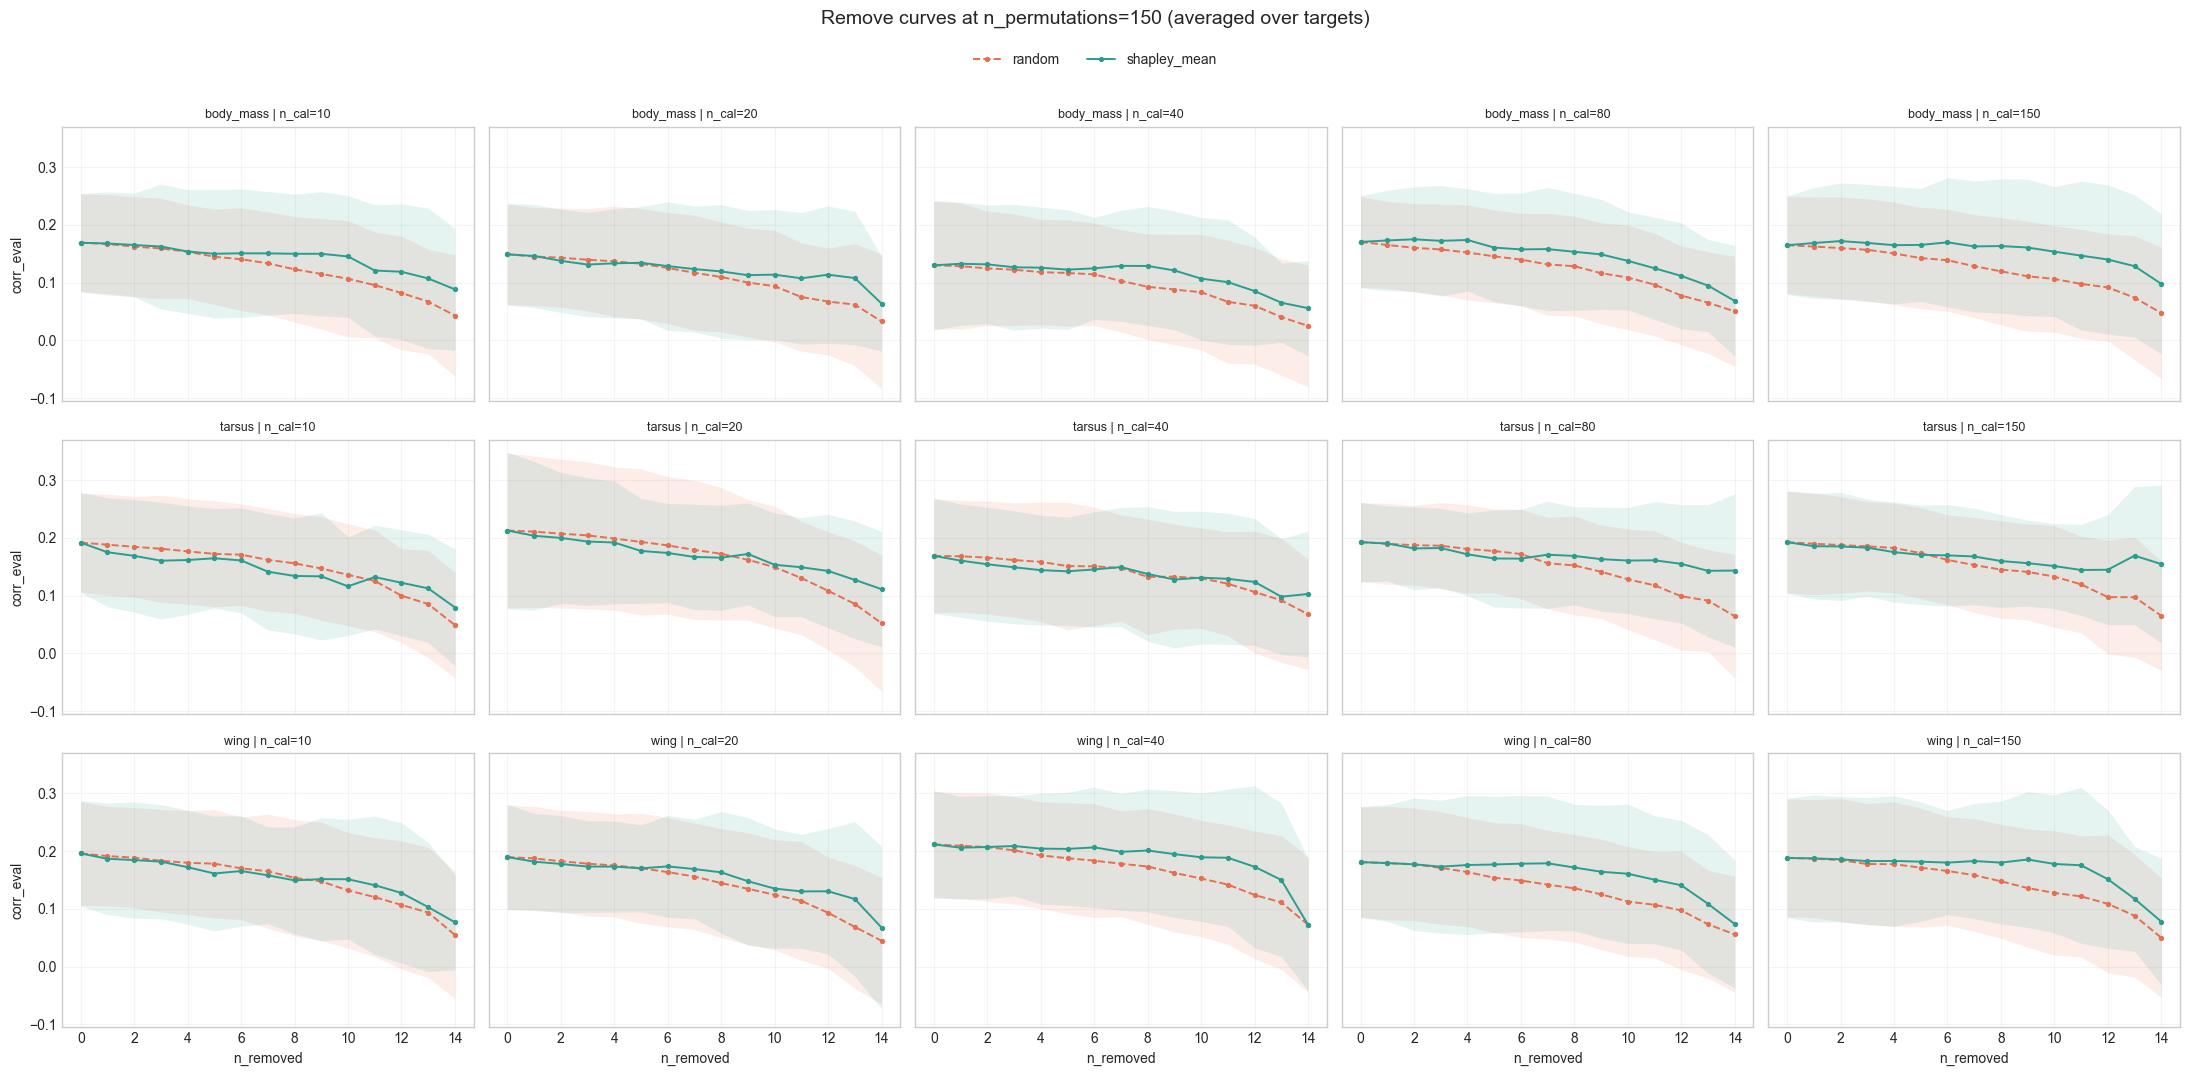

: 

In [ ]:
PLOT_N_PERM = 150

cal_vals = sorted([float(x) for x in cal_values])
n_rows = len(traits)
n_cols = len(cal_vals)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.4 * n_cols, 3.4 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
 )

for i, trait in enumerate(traits):
    for j, cal_val in enumerate(cal_vals):
        ax = axes[i, j]
        plot_any = False

        # pool repeat-level rows across targets for this (trait, cal, n_perm)
        pooled = []
        for target in target_codes:
            key = (trait, target)
            if key not in combo_data:
                continue

            raw = combo_data[key]['remove_rows'].copy()
            if raw.empty or 'method' not in raw.columns:
                continue

            sub = raw.copy()
            sub = sub[sub['n_permutations'].astype(int) == int(PLOT_N_PERM)].copy()
            if sub.empty:
                continue

            if cal_key in sub.columns:
                sub = sub[np.isclose(sub[cal_key].astype(float), float(cal_val))].copy()
            if sub.empty:
                continue

            # Normalize method names so all random variants get plotted together
            method_str = sub['method'].astype(str).str.lower()
            sub['method_group'] = np.where(
                method_str.eq('shapley_mean'),
                'shapley_mean',
                np.where(method_str.str.contains('random', regex=False), 'random', 'other')
            )
            sub = sub[sub['method_group'].isin(['shapley_mean', 'random'])].copy()
            if sub.empty:
                continue

            if 'corr_eval' not in sub.columns and 'corr_mean' in sub.columns:
                sub['corr_eval'] = sub['corr_mean']
            if 'corr_eval' not in sub.columns:
                continue

            pooled.append(sub[['method_group', 'n_removed', 'corr_eval']].copy())

        if pooled:
            pooled_df = pd.concat(pooled, ignore_index=True)
            stats = (
                pooled_df.groupby(['method_group', 'n_removed'], as_index=False)
                .agg(corr_mean=('corr_eval', 'mean'), corr_std=('corr_eval', 'std'))
                .sort_values(['method_group', 'n_removed'])
            )

            for method_group, g in stats.groupby('method_group'):
                x = g['n_removed'].to_numpy(dtype=float)
                y = g['corr_mean'].to_numpy(dtype=float)
                ystd = g['corr_std'].fillna(0.0).to_numpy(dtype=float)

                if method_group == 'shapley_mean':
                    color, ls, label = '#2A9D8F', '-', 'shapley_mean'
                else:
                    color, ls, label = '#E76F51', '--', 'random'

                ax.plot(x, y, marker='o', markersize=2.8, linewidth=1.4, linestyle=ls, color=color, label=label)
                ax.fill_between(x, y - ystd, y + ystd, color=color, alpha=0.12, linewidth=0)
                plot_any = True

        if cal_key == 'n_cal_samples':
            cal_txt = f"n_cal={int(round(cal_val))}"
        else:
            cal_txt = f"cal={cal_val:.2f}"

        ax.set_title(f"{trait} | {cal_txt}", fontsize=9)
        ax.grid(alpha=0.2)
        if i == n_rows - 1:
            ax.set_xlabel('n_removed')
        if j == 0:
            ax.set_ylabel('corr_eval')
        if not plot_any:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center', fontsize=9, alpha=0.7)

# single legend for the whole figure (collect handles across all axes)
legend_handles = {}
for row_axes in axes:
    for ax in row_axes:
        handles, labels = ax.get_legend_handles_labels()
        for h, lab in zip(handles, labels):
            if lab not in legend_handles:
                legend_handles[lab] = h
if legend_handles:
    fig.legend(
        list(legend_handles.values()),
        list(legend_handles.keys()),
        loc='upper center',
        ncol=len(legend_handles),
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )

fig.suptitle('Remove curves at n_permutations=150 (averaged over targets)', fontsize=14, y=1.05)
fig.tight_layout()
plt.show()

## 5) Phi-per-individual by source island (average over traits, one panel per target)

This figure uses the running-ranking files and averages `phi_per_ind_mean` across traits for each target island.
Panels are stacked horizontally (one subplot per target island).

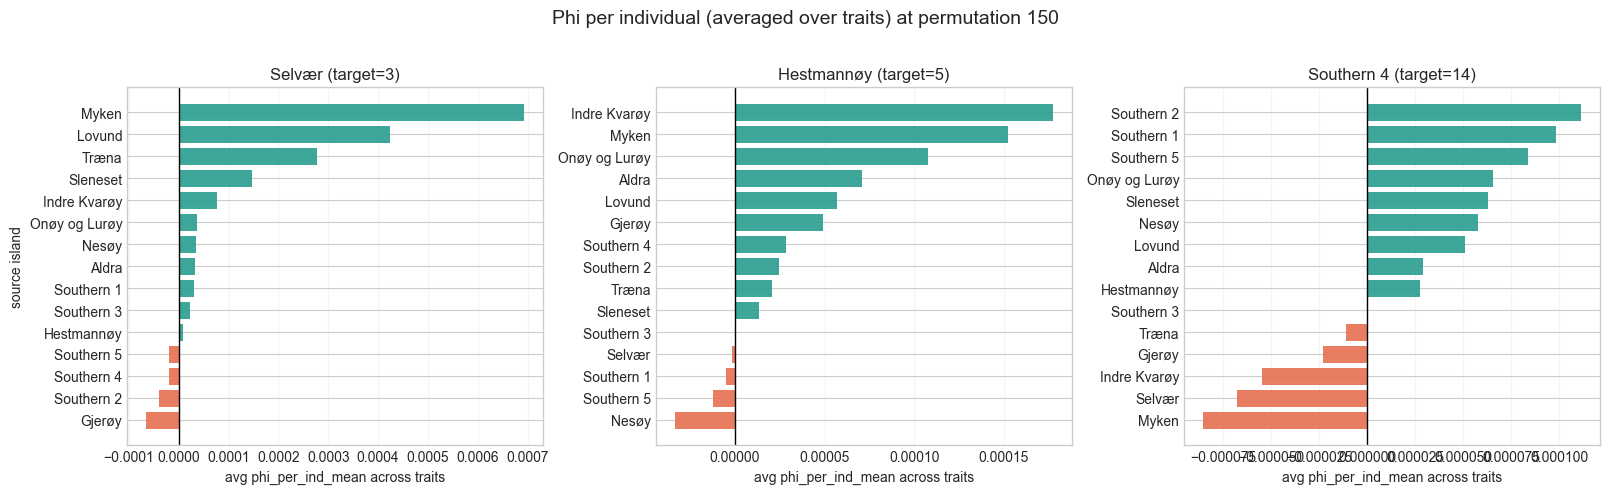

In [10]:
PLOT_N_PERM = 150
TOP_N_BARS = 15

n_targets = len(target_codes)
fig, axes = plt.subplots(1, n_targets, figsize=(5.4 * n_targets, 4.8), sharex=False, sharey=False)
axes = np.array(axes).reshape(1, n_targets)

for j, target in enumerate(target_codes):
    ax = axes[0, j]
    per_trait_rows = []

    for trait in traits:
        key = (trait, target)
        if key not in combo_data:
            continue
        rank_df = combo_data[key]['rank']
        if rank_df is None or rank_df.empty:
            continue
        if 'permutation_index' not in rank_df.columns or 'phi_per_ind_mean' not in rank_df.columns:
            continue

        pmax = int(rank_df['permutation_index'].max())
        p_use = int(min(PLOT_N_PERM, pmax))
        sub = rank_df[rank_df['permutation_index'] == p_use].copy()
        if sub.empty:
            continue

        keep_cols = ['source_island_name', 'phi_per_ind_mean']
        if not all(col in sub.columns for col in keep_cols):
            continue
        tmp = sub[keep_cols].copy()
        tmp['trait'] = trait
        tmp['perm_used'] = p_use
        per_trait_rows.append(tmp)

    if not per_trait_rows:
        ax.text(0.5, 0.5, 'no running-rank data', transform=ax.transAxes, ha='center', va='center')
        ax.axis('off')
        continue

    pooled = pd.concat(per_trait_rows, ignore_index=True)
    avg_df = (
        pooled.groupby('source_island_name', as_index=False)
        .agg(phi_per_ind_mean=('phi_per_ind_mean', 'mean'))
        .sort_values('phi_per_ind_mean', ascending=False)
    )

    top = avg_df.head(TOP_N_BARS).iloc[::-1]
    vals = top['phi_per_ind_mean'].to_numpy(dtype=float)
    colors = ['#2A9D8F' if v >= 0 else '#E76F51' for v in vals]
    ax.barh(top['source_island_name'].astype(str), vals, color=colors, alpha=0.9)
    ax.axvline(0.0, color='black', linewidth=1)
    ax.set_xlabel('avg phi_per_ind_mean across traits')
    if j == 0:
        ax.set_ylabel('source island')
    tname = target_name_map.get(target, str(target))
    ax.set_title(f"{tname} (target={target})")
    ax.grid(alpha=0.2, axis='x')

fig.suptitle('Phi per individual (averaged over traits) at permutation 150', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()